In [159]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.integrate import simps
from astropy import units as u
from astropy.coordinates import SkyCoord
from matplotlib import rc
#rc('font',**{'family':'serif','serif':['Palatino']})
#rc('text', usetex=True)

In [160]:
def deg_to_rad(theta):
    return theta * (np.pi/180)
def helio_to_lsr(vhelio,glon,glat):
    glon,glat = deg_to_rad(glon),deg_to_rad(glat)
    
    lon0,lat0 = 22.7,56.16
    
    lon0,lat0 = deg_to_rad(lon0),deg_to_rad(lat0)
    
    v_lsr = vhelio + 19.7*(np.sin(glat) * np.sin(lat0) + np.cos(glat) * np.cos(lat0) * np.cos(glon-lon0))
    return v_lsr

def simps_int(x,y,sigma_ypl=None,sigma_ymin=None):
    dx = x[1] - x[0]
    if len(x) % 2 == 1:
        x = x[:-1]
        y = y[:-1]

        sigma_ypl = sigma_ypl[:-1]
        
        sigma_ymin = sigma_ymin[:-1]
        
    
    integral = (dx/3) * (y[0] + y[-1])
    
    #inside the square root
    sigma_intpl =  sigma_ypl[0]**2 + sigma_ypl[-1]**2
    sigma_intmin = sigma_ymin[0]**2 + sigma_ymin[-1]**2
    len_remaining = len(x) - 2
    simps_iter = len_remaining//2
    
    
    for n in range(simps_iter):
        #Odd-numbered terms
        i = n//2 + 1
        
        integral += (dx/3) * 4 * y[i]
        sigma_intpl += (4 * sigma_ypl[i])**2
        sigma_intmin += (4 * sigma_ymin[i])**2
        
        #Even numbered terms
        integral+= (dx/3) * 2 * y[i+1]
        sigma_intpl += (2 * sigma_ypl[i+1])**2
        sigma_intmin += (2 * sigma_ymin[i+1])**2
    
    
    sigma_intpl = (dx/3) * np.sqrt(sigma_intpl)
    sigma_intmin = (dx/3) * np.sqrt(sigma_intmin)
    
    return {'int': integral, 'sigma+': sigma_intpl, 'sigma-': sigma_intmin}
    
        
        
    
    
        
        
        
        
        
    



In [161]:
fname = '../Data/RBS144_coadd_FUVM_final_lpALL.fits'
fits_dframe = fits.open(fname)

In [162]:
linelist_fname = '../Data/linelist.dat'

In [163]:
fits_dframe[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  144 / length of dimension 1                          
NAXIS2  =                80935 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   18 / number of table fields                         
TTYPE1  = 'WAVE    '                                                            
TFORM1  = 'D       '                                                            
TTYPE2  = 'FLUX    '                                                            
TFORM2  = 'D       '                                                            
TTYPE3  = 'ERROR   '        

$\alpha=15.113^\circ$ $\delta=-51.2318^\circ$
$\alpha = $01h00m27.12s; $\delta = -51^\circ$13$m$54.48$s

In [164]:
c_icrs = SkyCoord(ra=15.113*u.degree, dec=-51.2318*u.degree, frame='icrs')
c_icrs.galactic

<SkyCoord (Galactic): (l, b) in deg
    (299.48357441, -65.83605628)>

In [165]:
N_a

11.240707844952095

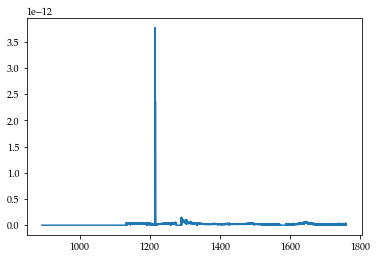

In [166]:
%matplotlib inline
wl = fits_dframe[1].data['WAVE']
flux = fits_dframe[1].data['FLUX']
err_up = fits_dframe[1].data['FLUXERR_UP']
err_down = fits_dframe[1].data['FLUXERR_DOWN']
plt.plot(wl,flux)

In [167]:
HI_vel,Tb = np.genfromtxt('../Data/spectrum.txt',skip_header=14,skip_footer=780).T

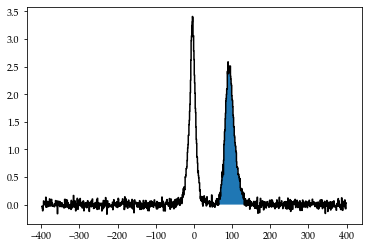

In [168]:
plt.step(HI_vel,Tb,'k-')
comp_mask = (HI_vel > 50) & (HI_vel < 160)
plt.fill_between(HI_vel[comp_mask],Tb[comp_mask])
NHI_lin = -1.823e18 * simps(Tb[comp_mask],x=HI_vel[comp_mask])
NHI = np.log10(NHI_lin)
plt.show()

In [169]:
noise_mask = (HI_vel <= -50)
noisy_T = Tb[noise_mask]
vnoise = HI_vel[noise_mask]

T_rms = np.sqrt(np.mean(noisy_T**2))
FWHM = 25. #km/s

NHI_det_lim = 1.823e18 * T_rms * np.sqrt((HI_vel[0]-HI_vel[1]) * FWHM)
sigma_NHI = NHI_det_lim / (np.log(10) * NHI_lin)
S_to_N = 10**NHI/(3*NHI_det_lim)
print('log(NHI) = %.3f +/- %.3f' % (NHI, sigma_NHI))
S_to_N

log(NHI) = 20.129 +/- 0.001


106.26967343320402

In [170]:
wave = {'SiII_1190': 1190.4158, 'SiII_1193':1193.2897,'SiII_1260':1260.4221,\
          'SiII_1304': 1304.3702, 'SiII_1526': 1526.7066, 'SiIII_1206': 1206.5000,\
         'SiIV_1393': 1393.7550, 'SiIV_1402': 1402.7700, 'OI_1302': 1302.1680, 'SiI_1540': 1540.3538,\
       'NI_1200': 1200.2230}
f_val = {'SiII_1190': 2.84e-01, 'SiII_1193': 5.94e-01, 'SiII_1260': 1.45e+00,\
        'SiII_1304': 1.06e-01, 'SiII_1526': 1.27e-01, 'SiIII_1206': 1.70e+00,\
        'SiIV_1393': 5.36e-01, 'SiIV_1402': 2.62e-01, 'OI_1302': 5.20e-02, \
         'SiI_1540': 6.61e-01, 'NI_1200': 8.70e-02}
ion_waves = ['SiII_1190','SiII_1193','SiII_1260','SiII_1304','SiII_1526','SiIII_1206',\
            'SiIV_1393','SiIV_1402','OI_1302']

In [171]:
spec_snips = {}

for ion_wave in ion_waves:
    l0 = wave[ion_wave]
    f = f_val[ion_wave]
    vel_helio = 299792.458 * (wl - l0)/l0
    vel = helio_to_lsr(vel_helio,299.48,-65.8)
    vmin,vmax = -450.,+450
    
    vmask = (vel > vmin) & (vel < vmax)
    
    new_vel = vel[vmask]
    new_flux = flux[vmask]
    new_errup = err_up[vmask]
    new_errdown = err_down[vmask]
    spec_snips[ion_wave] = {'vel':new_vel,'flux':new_flux,'err+':new_errup,'err-':new_errdown}
    
    
    

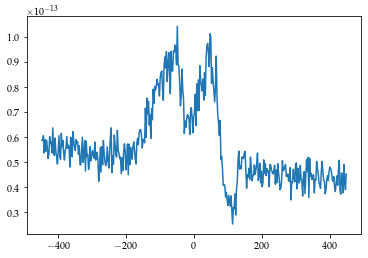

In [71]:
%matplotlib inline
v = spec_snips['OI_1302']['vel']
f = spec_snips['OI_1302']['flux']
#c = normalized_
plt.plot(v,f)

In [72]:
norm_masks = {'SiII_1190':[[-500.,-100.],[230.,500.]],'SiII_1193': [[-500.,-100.],[230.,500.]],\
             'SiII_1260': [[-500,-250],[-170,-60],[230.,500.]],'SiII_1304':[[-500.,-36.],[23.,95.],[150.,500.]],\
             'SiII_1526': [[-500.,-40.],[50.,85.],[150.,500.]],'SiIII_1206':[[-500.,-60.],[220.,500.]],\
             'SiIV_1393':[[-500.,-100.],[180.,500.]],'SiIV_1402':[[-500,-30.],[150.,500.]],\
              'OI_1302':[[-500.,-30.],[50.,85.],[150.,500.]]}



In [73]:
normalized = {}
for ion_wave in ion_waves:
    vel0,flux0,errup0,errdown0 = spec_snips[ion_wave]['vel'],spec_snips[ion_wave]['flux'],\
    spec_snips[ion_wave]['err+'],spec_snips[ion_wave]['err-']
    
    norm_regs = norm_masks[ion_wave]
    tot_mask = (vel0 >= norm_regs[0][0]) & (vel0 <= norm_regs[0][1])
    
    for reg in norm_regs:
        partial_mask = (vel0 >= reg[0]) & (vel0 <= reg[1])
        
        tot_mask = np.logical_or(tot_mask,partial_mask)
    
    vnorm = vel0[tot_mask]
    fnorm = flux0[tot_mask]
    errunorm = errup0[tot_mask]
    errdnorm = errdown0[tot_mask]
    
    weight = (0.5*(errunorm + errdnorm))**-2
    
    
    if (ion_wave == 'SiII_1304') or (ion_wave == 'OI_1302'):
        degree=15
    elif (ion_wave == 'SiII_1260') or (ion_wave == 'SiIV_1402'):
        degree=5
    else:
        degree=3
    
    #print(degree)
    popt = np.polyfit(vnorm,fnorm,deg=degree,w=weight)
    print(popt)
    
    cont = np.polyval(popt,x=vel0)
    
    cont_reg = np.polyval(popt,x=vnorm)
    
    norm_flux = flux0/cont
    norm_erru = errup0/cont
    norm_errd = errdown0/cont
    
    
    err_avg = (errunorm+errdnorm)/2
    
    chi2 = np.sum(((cont_reg - fnorm)/err_avg)**2)
    
    dof = len(err_avg) - degree - 1
    
    redchi2 = chi2/dof
    
    normalized[ion_wave] = {'vel':vel0,'norm':norm_flux,'err+':norm_erru,'err-': norm_errd,'cont': cont,\
                            'norm_mask':tot_mask,'redchi2':redchi2}
    
    
    
    

[-1.65755311e-23 -2.19267584e-21  1.94017369e-18  2.64934958e-14]
[-1.19379322e-23  1.28627005e-22  2.16806377e-18  2.63863424e-14]
[-2.41219554e-28  7.45578240e-26  2.87024881e-23  6.66908828e-21
  5.07400822e-18  2.86901879e-14]
[ 4.03039366e-51  3.83513229e-49 -2.76911812e-45 -3.78284862e-43
  7.27384517e-40  1.47674460e-37 -8.85290757e-35 -2.87729701e-32
  4.21483513e-30  2.91188397e-27  8.35959024e-26 -1.42971550e-22
 -1.49681030e-20  2.62110266e-18  4.24553066e-16  5.51176628e-14]
[ 7.70086013e-23  3.14873404e-20 -1.10920666e-17  1.30628995e-14]
[ 2.38269228e-23  8.61240796e-21 -8.40470869e-18  2.20402226e-14]
[-6.02452213e-24  2.43951569e-21 -6.59885421e-19  2.03894733e-14]
[-1.43308339e-28  1.30928170e-25  1.60558332e-23 -2.05242920e-20
  8.83407649e-19  1.95292469e-14]
[ 2.66375076e-52 -1.16431624e-49 -2.84093015e-46  1.24078326e-43
  1.23626966e-40 -5.07602204e-38 -2.86627355e-35  1.05454322e-32
  3.83105930e-30 -1.21762183e-27 -2.94117078e-25  7.93336174e-23
  1.18747631e-20

In [74]:
for ion_wave in ion_waves:
    print(ion_wave+' reduced chi-squared = %.2f' % normalized[ion_wave]['redchi2'])

SiII_1190 reduced chi-squared = 1.19
SiII_1193 reduced chi-squared = 1.18
SiII_1260 reduced chi-squared = 1.26
SiII_1304 reduced chi-squared = 1.75
SiII_1526 reduced chi-squared = 2.68
SiIII_1206 reduced chi-squared = 1.08
SiIV_1393 reduced chi-squared = 1.19
SiIV_1402 reduced chi-squared = 1.20
OI_1302 reduced chi-squared = 1.52


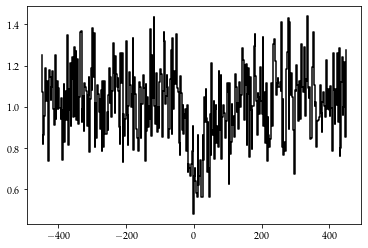

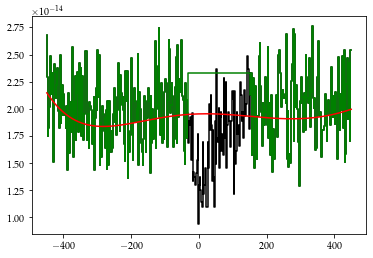

Reduced chi-squared = 1.20


In [75]:
%matplotlib inline
v = normalized['SiIV_1402']['vel']
f = normalized['SiIV_1402']['norm']
#plt.hlines(y=1.,xmin=min(v),xmax=max(v))
c = normalized['SiIV_1402']['cont']
plt.step(v,f,'k-')
#plt.plot(v,c,'r-')
norm_mask = normalized['SiIV_1402']['norm_mask']
#plt.step(v[norm_mask],f[norm_mask],'g-')
comp_mask = (v >= 75.) & (v <= 160.)
plt.show()
v = spec_snips['SiIV_1402']['vel']
f = spec_snips['SiIV_1402']['flux']
#plt.hlines(y=1.,xmin=min(v),xmax=max(v))
c = normalized['SiIV_1402']['cont']
plt.step(v,f,'k-')

norm_mask = normalized['SiIV_1402']['norm_mask']
plt.step(v[norm_mask],f[norm_mask],'g-')
plt.plot(v,c,'r-')
comp_mask = (v >= 75.) & (v <= 160.)
plt.show()
print('Reduced chi-squared = %.2f' % normalized['SiIV_1402']['redchi2'])

In [76]:
comp_masks = {'SiII_1190':[60.,160.],'SiII_1193':[75.,160.],'SiII_1260':[75.,160],'SiII_1304':[92.,160.],\
             'SiII_1526':[75.,160.],'SiIII_1206':[75.,160.],'SiIV_1393':[75.,160.],'SiIV_1402':[75.,160.],\
             'OI_1302':[80.,160.]}

In [77]:
final = {}
for ion_wave in ion_waves:
    v,n,eru,erd = normalized[ion_wave]['vel'],normalized[ion_wave]['norm'],\
    normalized[ion_wave]['err+'],normalized[ion_wave]['err-']
    
    comp_reg = comp_masks[ion_wave]
    
    l0 = wave[ion_wave]
    f = f_val[ion_wave]
    print(ion_wave)
    
    comp_mask = (v >= comp_reg[0]) & (v <= comp_reg[1])
    
    N_a_tot = []
    v_avgs = []
    v_sigmas = []
    
    
    N_a_lin = np.mean(N_a_tot)
    N_a_lin_sigma = np.std(N_a_tot)
    N_a = np.log10(N_a_lin)
    N_a_sigma = N_a_lin_sigma / (np.log(10) * N_a_lin)
    
  
    N_a_raw_func = 3.768e14/(f*l0) * np.log(abs(1/n))
    
    N_a_raw = np.log10(abs(simps_int(x=v[comp_mask],y=N_a_raw_func[comp_mask],sigma_ypl = eru,sigma_ymin=erd)['int']))
    
    
    avg_v = np.mean(v_avgs)
    avg_v_sigma = np.std(v_avgs)
    
    sigma_v = np.mean(v_sigmas)
    sigma_v_sigma = np.std(v_sigmas)
    
    final[ion_wave] = {'vel': v,'norm': n,'err+':eru,'err-':erd,'cont': normalized[ion_wave]['cont'],\
                      'N_a': N_a,'N_a_sigma':N_a_sigma,'avg_v':avg_v,'avg_v_sigma':avg_v_sigma,\
                      'sigma_v':sigma_v,'sigma_v_sigma':sigma_v_sigma,'N_a_raw': N_a_raw,'N_a_raw_func':N_a_raw_func}
    
    
    

SiII_1190
SiII_1193
SiII_1260
SiII_1304
SiII_1526
SiIII_1206
SiIV_1393
SiIV_1402
OI_1302


/opt/anaconda3/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:221: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:253: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


# Monte-Carlo 

SiII_1190


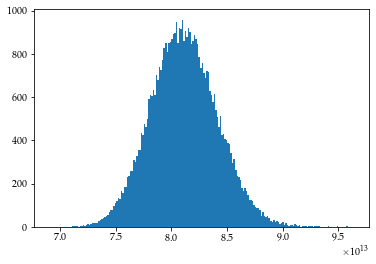

SiII_1193


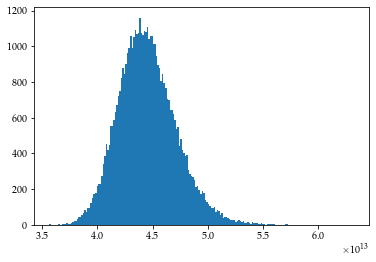

SiII_1260


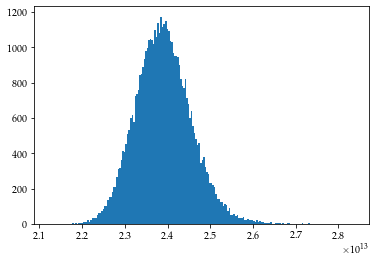

SiII_1304


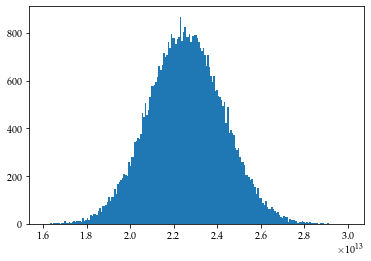

SiII_1526


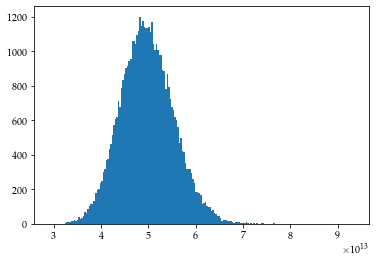

SiIII_1206


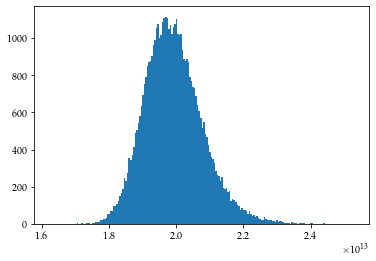

<ipython-input-78-44bc889c23ab>:47: RuntimeWarning: invalid value encountered in log
  N_a_raw_func = 3.768e14/(f*l0) * np.log(1/n)


SiIV_1393


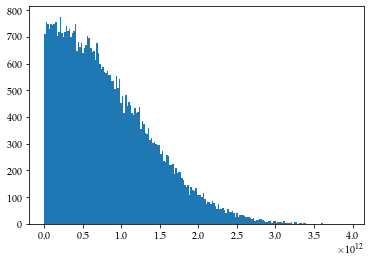

SiIV_1402


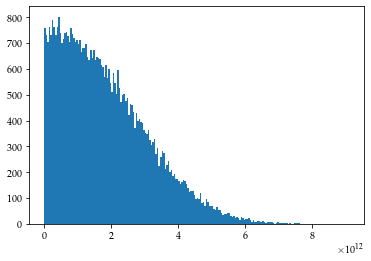

OI_1302


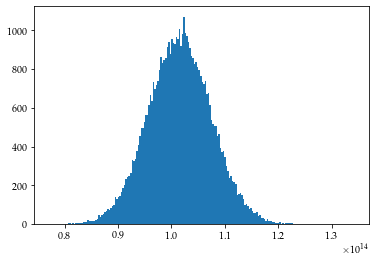

In [78]:
final = {}
for ion_wave in ion_waves:
    v,n,eru,erd = normalized[ion_wave]['vel'],normalized[ion_wave]['norm'],\
    normalized[ion_wave]['err+'],normalized[ion_wave]['err-']
    
    comp_reg = comp_masks[ion_wave]
    
    l0 = wave[ion_wave]
    f = f_val[ion_wave]
    print(ion_wave)
    
    comp_mask = (v >= comp_reg[0]) & (v <= comp_reg[1])
    
    N_a_tot = []
    v_avgs = []
    v_sigmas = []
    for i in range(50000):
        norm_test = n + abs(np.random.normal(0.,eru)) - abs(np.random.normal(0.,erd))
        #norm_mask = norm_test > 0
        tot_mask = comp_mask
        
        
        
        
        
        N_a_lin_func = 3.768e14/(f * l0) * np.log(abs(1/norm_test))
        N_a_lin_tot = abs(simps(N_a_lin_func[tot_mask],x=v[tot_mask]))
        
        v_avg = abs(simps(N_a_lin_func[tot_mask]*v[tot_mask],x=v[tot_mask]))/N_a_lin_tot
        v_avgs.append(v_avg)
        
        v_sigma = np.sqrt(abs(simps(N_a_lin_func[tot_mask]*(v[tot_mask]-v_avg)**2,x=v[tot_mask]))/N_a_lin_tot)
        v_sigmas.append(v_sigma)
        
        
        N_a_tot.append(N_a_lin_tot)
    
    plt.hist(N_a_tot,bins=200)
    plt.show()
    
    N_a_lin = np.mean(N_a_tot)
    N_a_lin_sigma = np.std(N_a_tot)
    N_a = np.log10(N_a_lin)
    N_a_sigma = N_a_lin_sigma / (np.log(10) * N_a_lin)
    
  
    N_a_raw_func = 3.768e14/(f*l0) * np.log(1/n)
    
    N_a_raw = np.log10(abs(simps(N_a_raw_func[comp_mask],x=v[comp_mask])))
    
    
    avg_v = np.mean(v_avgs)
    avg_v_sigma = np.std(v_avgs)
    
    sigma_v = np.mean(v_sigmas)
    sigma_v_sigma = np.std(v_sigmas)
    
    final[ion_wave] = {'vel': v,'norm': n,'err+':eru,'err-':erd,'cont': normalized[ion_wave]['cont'],\
                      'N_a': N_a,'N_a_sigma':N_a_sigma,'avg_v':avg_v,'avg_v_sigma':avg_v_sigma,\
                      'sigma_v':sigma_v,'sigma_v_sigma':sigma_v_sigma,'N_a_raw': N_a_raw,'N_a_raw_func':N_a_raw_func}
    
    
    

In [79]:
N = final['SiII_1193']['N_a']
sig = final['SiII_1193']['N_a_sigma']
print('%.2f +/- %.2f' % (N,sig))
noise_level = 3 * np.log(10) * 10**N * sig
s_to_n = 10**N/noise_level 
print('S/N = %.2f' % s_to_n)

13.65 +/- 0.03
S/N = 5.61


In [80]:
13.91-20.13-7.51+12

-1.7299999999999986

In [81]:
for ion_wave in ion_waves:
    S2Ns = {}
    #print(ion_wave)
    N = final[ion_wave]['N_a_raw']
    sig = final[ion_wave]['N_a_sigma']
    #rint('%.3f +/- %.3f' % (N,sig))
    noise_level = 3*np.log(10) * 10**N * sig
    s_to_n = 10**N/noise_level 
    S2Ns[ion_wave] = s_to_n
    print(ion_wave+': %.2f' % s_to_n)

    
        
        

SiII_1190: 9.02
SiII_1193: 5.61
SiII_1260: 12.15
SiII_1304: 4.37
SiII_1526: 2.92
SiIII_1206: 7.61
SiIV_1393: 0.45
SiIV_1402: 0.46
OI_1302: 5.78


In [82]:
N_SiII = final['SiII_1190']['N_a_raw']
sig_SiII = final['SiII_1190']['N_a_sigma']
sig_SiII_lin = np.log(10) * sig_SiII * 10**N_SiII
print('%.2f +/- %.2f' % (N_SiII,sig_SiII))
noise_level_SiII = 3*np.log(10) * 10**N_SiII * sig_SiII
s_to_n = 10**N_SiII/noise_level_SiII
print('S/N = %.2f' % s_to_n)

13.91 +/- 0.02
S/N = 9.02


In [83]:
N_SiIII = final['SiIII_1206']['N_a_raw']
sig_SiIII = final['SiIII_1206']['N_a_sigma']
sig_SiIII_lin = np.log(10) * sig_SiIII * 10**N_SiIII
print('%.2f +/- %.2f' % (N_SiIII,sig_SiIII))
noise_level_SiIII = 3*np.log(10) * 10**N_SiIII * sig_SiIII
s_to_n = 10**N_SiIII/noise_level_SiIII 
print('S/N = %.2f' % s_to_n)

13.31 +/- 0.02
S/N = 7.61


In [84]:
N_SiIV = final['SiIV_1402']['N_a_raw']
sig_SiIV = final['SiIV_1402']['N_a_sigma']
sig_SiIV_lin = np.log(10) * sig_SiIV * 10**N_SiIV
print('%.2f +/- %.2f' % (N_SiIV,sig_SiIV))
noise_level_SiIV = 3*np.log(10) * 10**N_SiIV * sig_SiIV
s_to_n = 10**(N_SiIV)/noise_level_SiIV
noise_level_SiIV_log = np.log10(3*noise_level_SiIV)
print('S/N = %.2f' % s_to_n)
print('N_SiIV < %.2f' % noise_level_SiIV_log)

11.92 +/- 0.31
S/N = 0.46
N_SiIV < 12.73


In [85]:
N_OI = final['OI_1302']['N_a_raw']
sig_OI = final['OI_1302']['N_a_sigma']
print('%.2f +/- %.2f' % (N_OI,sig_OI))
noise_level_OI = np.log(10) * 10**N_OI * sig_OI
s_to_n = 10**N_OI/noise_level 
print('S/N = %.2f' % s_to_n)

OI_HI = N_OI - NHI + 12. - 8.69
OI_HI_sigma = np.sqrt(sig_OI**2 + sigma_NHI**2)
print('[OI/HI] = %.2f +/- %.2f' % (OI_HI,OI_HI_sigma))

14.00 +/- 0.03
S/N = 5.78
[OI/HI] = -2.82 +/- 0.03


In [86]:
N_Si_gas = np.log10(10**N_SiII + 10**N_SiIII + 10**N_SiIV)
sigma_Si_lin = np.sqrt(sig_SiII_lin**2 + sig_SiIII_lin**2 + sig_SiIV_lin**2)
sigma_Si_gas = sigma_Si_lin/(np.log(10) * 10**N_Si_gas)
print('N_Si_tot = %.2f +/- %.2f' % (N_Si_gas,sigma_Si_gas))

N_Si_tot = 14.01 +/- 0.01


In [87]:
Si_H_sun = 7.51 - 12.00
Zcloud = -1.00 #solar
Si_dust_depletion = 0.61

$N_\rm{H,tot} = \left(\frac{N_{\rm{SiII}}+N_{\rm{SiIII}}+N_{\rm{SiIV}}}{Z_{\rm{cloud}}\left(\frac{\rm{Si}}{\rm{H}}\right)_\odot}\right) \rm{DDF}$

In [88]:
NH_tot = N_Si_gas - Zcloud - Si_H_sun
NH_tot

19.501849208362415

In [89]:
Si_HI = N_Si_gas - NHI+12-7.51
Si_HI

-1.6271683747151098

In [90]:
chi_HII = 1 - 10**(NHI - NH_tot)
chi_HI = 10**(NHI - NH_tot)

In [91]:
NHI

20.129017583077527

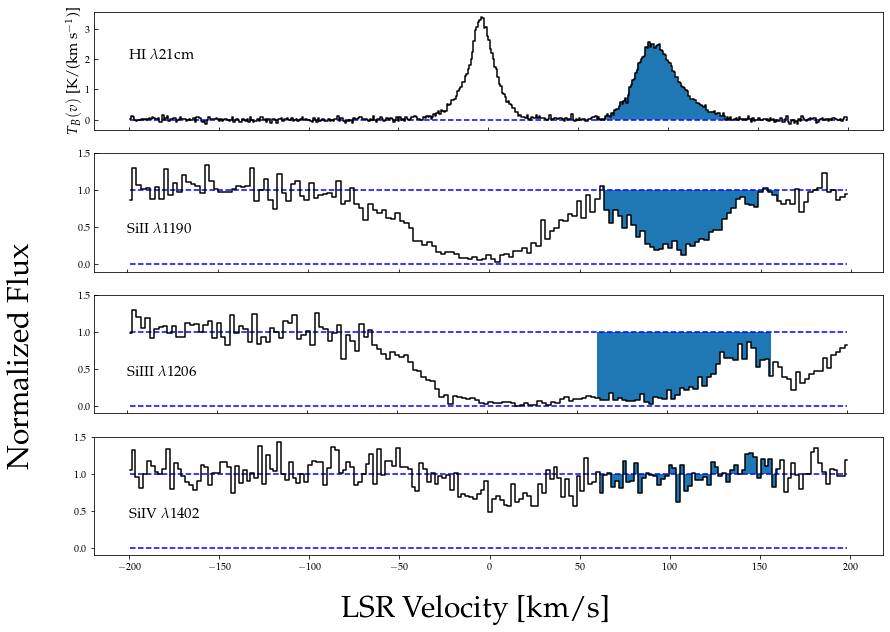

In [94]:
fig,axs = plt.subplots(4,1,figsize=(10*np.sqrt(2),10))
HI_mask = (HI_vel > -200.) & (HI_vel < 200.)
HI_comp_mask = (HI_vel > 60) & (HI_vel < 160)
 
axs[0].step(HI_vel[HI_mask],Tb[HI_mask],'k-')
axs[0].fill_between(HI_vel[HI_comp_mask],Tb[HI_comp_mask])
#ax[0].text(-150.,2.,r'GASS HI$\lambda$21cm')
axs[0].tick_params(left = True, right = False , labelleft = True ,labelbottom = False, bottom = True,direction='in')
axs[0].hlines(0,xmin=min(HI_vel[HI_mask]),xmax=max(HI_vel[HI_mask]),color='b',linestyle='dashed')
axs[0].annotate(r'HI $\lambda$21cm',(-200.,2),fontsize=15)
axs[0].set_ylabel(r'$T_B(v)$ [K/(km s$^{-1}$)]',fontsize=15)

v = normalized['SiII_1190']['vel']
f = normalized['SiII_1190']['norm']

mask = (v > -200.) & (v < 200.)
comp_mask = (v > 60.) & (v < 160)

axs[1].step(v[mask],f[mask],'k-',where='mid')
axs[1].fill_between(v[comp_mask],1,f[comp_mask],step='mid')
axs[1].hlines(1,xmin=min(v[mask]),xmax=max(v[mask]),color='b',linestyle='dashed')
axs[1].hlines(0,xmin=min(v[mask]),xmax=max(v[mask]),color='b',linestyle='dashed')

axs[1].annotate(r'SiII $\lambda$1190',(-200.,0.4),fontsize=15)
axs[1].set_ylim(ymin=-0.1,ymax=1.5)
axs[1].tick_params(left = True, right = False , labelleft = True ,labelbottom = False, bottom = True,direction='in')
axs[2].tick_params(left = True, right = False , labelleft = True ,labelbottom = False, bottom = True,direction='in')



v = normalized['SiIII_1206']['vel']
f = normalized['SiIII_1206']['norm']
mask = (v > -200.) & (v < 200.)
comp_mask = (v > 60.) & (v < 160)

axs[2].step(v[mask],f[mask],'k-',where='mid')
axs[2].fill_between(v[comp_mask],1,f[comp_mask],step='mid')
axs[2].hlines(1,xmin=min(v[mask]),xmax=max(v[mask]),color='b',linestyle='dashed')
axs[2].hlines(0,xmin=min(v[mask]),xmax=max(v[mask]),color='b',linestyle='dashed')

axs[2].annotate(r'SiIII $\lambda$1206',(-200.,0.4),fontsize=15)
axs[2].set_ylim(ymin=-0.1,ymax=1.5)


v = normalized['SiIV_1402']['vel']
f = normalized['SiIV_1402']['norm']
mask = (v > -200.) & (v < 200.)
comp_mask = (v > 60.) & (v < 160)

axs[3].step(v[mask],f[mask],'k-',where='mid')
axs[3].fill_between(v[comp_mask],1,f[comp_mask],step='mid')
axs[3].hlines(1,xmin=min(v[mask]),xmax=max(v[mask]),color='b',linestyle='dashed')
axs[3].hlines(0,xmin=min(v[mask]),xmax=max(v[mask]),color='b',linestyle='dashed')

axs[3].annotate(r'SiIV $\lambda$1402',(-200.,0.4),fontsize=15)
axs[3].set_ylim(ymin=-0.1,ymax=1.5)

fig.text(0.04, 0.4, 'Normalized Flux', va='center', rotation='vertical',fontsize=30)

fig.text(0.5, 0.04, 'LSR Velocity [km/s]', ha='center',fontsize=30)
plt.savefig('Col_Flux_Plotstack.svg')
plt.show()


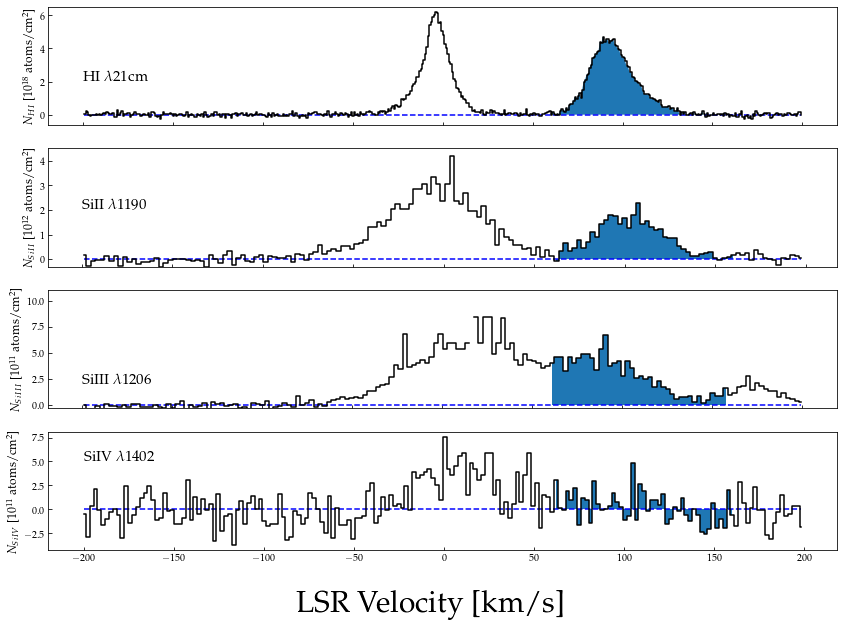

In [93]:
fig,axs = plt.subplots(4,1,figsize=(10*np.sqrt(2),10))
HI_mask = (HI_vel > -200.) & (HI_vel < 200.)
HI_comp_mask = (HI_vel > 60) & (HI_vel < 160)
NHI_func = 1.823e18 * Tb/1e18

axs[0].step(HI_vel[HI_mask],NHI_func[HI_mask],'k-')
axs[0].fill_between(HI_vel[HI_comp_mask],NHI_func[HI_comp_mask])
#ax[0].text(-150.,2.,r'GASS HI$\lambda$21cm')
axs[0].tick_params(left = True, right = False , labelleft = True ,labelbottom = False, bottom = True,direction='in')
axs[0].hlines(0,xmin=min(HI_vel[HI_mask]),xmax=max(HI_vel[HI_mask]),color='b',linestyle='dashed')
axs[0].annotate(r'HI $\lambda$21cm',(-200.,2),fontsize=15)
axs[0].set_ylabel(r'$N_{HI}$ [$10^{18}$ atoms/cm$^2$]',fontsize=12)

v = normalized['SiII_1190']['vel']
n = final['SiII_1190']['N_a_raw_func']/1e12

mask = (v > -200.) & (v < 200.)
comp_mask = (v > 60.) & (v < 160)

axs[1].step(v[mask],n[mask],'k-',where='mid')
axs[1].fill_between(v[comp_mask],n[comp_mask],step='mid')
axs[1].tick_params(left = True, right = False , labelleft = True ,labelbottom = False, bottom = True,direction='in')

#axs[1].hlines(1,xmin=min(v[mask]),xmax=max(v[mask]),color='b',linestyle='dashed')
axs[1].hlines(0,xmin=min(v[mask]),xmax=max(v[mask]),color='b',linestyle='dashed')

axs[1].annotate(r'SiII $\lambda$1190',(-200.,2.0),fontsize=15)
axs[1].set_ylabel(r'$N_{SiII}$ [$10^{12}$ atoms/cm$^2$]',fontsize=12)

axs[1].set_ylim(ymin=-0.3,ymax=4.5)



v = normalized['SiIII_1206']['vel']
n = final['SiIII_1206']['N_a_raw_func']/1e11
mask = (v > -200.) & (v < 200.)
comp_mask = (v > 60.) & (v < 160)

axs[2].step(v[mask],n[mask],'k-',where='mid')
axs[2].fill_between(v[comp_mask],n[comp_mask],step='mid')
#axs[2].hlines(1,xmin=min(v[mask]),xmax=max(v[mask]),color='b',linestyle='dashed')
axs[2].tick_params(left = True, right = False , labelleft = True ,labelbottom = False, bottom = True,direction='in')

axs[2].hlines(0,xmin=min(v[mask]),xmax=max(v[mask]),color='b',linestyle='dashed')

axs[2].annotate(r'SiIII $\lambda$1206',(-200.,2.0),fontsize=15)
axs[2].set_ylabel(r'$N_{SiIII}$ [$10^{11}$ atoms/cm$^2$]',fontsize=12)

axs[2].set_ylim(ymin=-0.3,ymax=11.)


v = normalized['SiIV_1402']['vel']
n = final['SiIV_1402']['N_a_raw_func']/1e11
mask = (v > -200.) & (v < 200.)
comp_mask = (v > 60.) & (v < 160)

axs[3].step(v[mask],n[mask],'k-',where='mid')
axs[3].fill_between(v[comp_mask],n[comp_mask],step='mid')
#axs[3].hlines(1,xmin=min(v[mask]),xmax=max(v[mask]),color='b',linestyle='dashed')
axs[3].hlines(0,xmin=min(v[mask]),xmax=max(v[mask]),color='b',linestyle='dashed')
axs[3].tick_params(left = True, right = False , labelleft = True ,labelbottom = True, bottom = True,direction='in')


axs[3].annotate(r'SiIV $\lambda$1402',(-200.,5.0),fontsize=15)
#axs[3].set_ylim(ymin=0,ymax=1.5)
axs[3].set_ylabel(r'$N_{SiIV}$ [$10^{11}$ atoms/cm$^2$]',fontsize=12)

#fig.text(0.04, 0.4, 'Normalized Flux', va='center', rotation='vertical',fontsize=30)

fig.text(0.5, 0.04, 'LSR Velocity [km/s]', ha='center',fontsize=30)
plt.savefig('Col_Dens_Plotstack.svg')
plt.show()


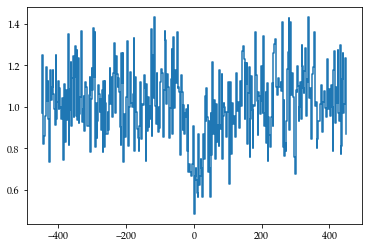

In [145]:
v,n = normalized['SiIV_1402']['vel'],normalized['SiIV_1402']['norm']
N_a = final['SiIV_1402']['N_a_raw']
redchi2 = normalized['SiIV_1402']['redchi2']
plt.step(v,n)
plt.show()

In [184]:
tau = 1000*np.exp(-(v/18.)**2)
phi = np.exp(-tau)
phi_noise = phi + np.random.normal(0.,0.04,len(phi))

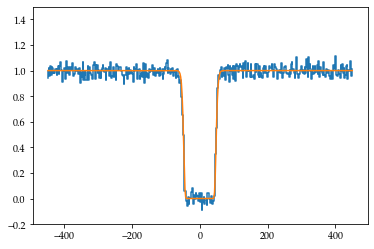

In [185]:
plt.step(v,phi_noise)
plt.plot(v,phi)
plt.ylim(ymin=-0.2,ymax=1.5)
plt.show()

In [186]:
f_lu = f_val['SiIII_1206']
l0 = wave['SiIII_1206']

In [187]:
N_a = 3.77e14 / (f_lu * l0) * np.log(abs(1/phi_noise))
N_meas = simps(N_a,x=v)
N_a_true = 3.77e14/(f_lu * l0) * tau
N_true = simps(N_a_true,x=v)

In [188]:
print('N_true = %.2f; N_measured = %.2f' % (np.log10(N_true),np.log10(N_meas)))

N_true = 15.77; N_measured = 13.83


In [189]:
eq_w = simps((1 - phi_noise),x=v)


In [248]:
tau_0s_log = np.linspace(-10,8,100000)
tau_0s = 10**tau_0s_log

In [249]:
N_trues = []
N_meass = []

eq_w_meass = []
eq_w_trues = []
for tau_0 in tau_0s:
    #print(tau_0)
   
    tau = tau_0*np.exp(-(v/18.)**2)
    phi = np.exp(-tau)
    phi_noise = phi + np.random.normal(0.,0.08,len(phi))
    
    eq_w_true = simps((1 - phi),x=v)
    eq_w_meas = simps((1 - phi_noise),x=v)
    
    eq_w_meass.append(eq_w_meas)
    eq_w_trues.append(eq_w_true)
    
    N_meas = 3.77e14/(f_lu*l0) * simps(np.log(abs(1/phi_noise)),x=v)
    N_meass.append(N_meas)
    N_true = 3.77e14/(f_lu*l0) * simps(tau,x=v)
    N_trues.append(N_true)
    
    
    
#N_trues = np.array(N_trues)
#N_meass = np.array(N_meass)
#eq_w_trues = np.array(eq_w_trues)
#eq_w_meass = np.array(eq_w_meass)

In [250]:
N_trues = np.log10(np.array(N_trues))
N_meass = np.log10(np.array(N_meass))
eq_w_trues = np.log10(np.array(eq_w_trues))
eq_w_meass = np.log10(np.array(eq_w_meass))

<ipython-input-250-20427a0a894a>:2: RuntimeWarning: invalid value encountered in log10
  N_meass = np.log10(np.array(N_meass))
<ipython-input-250-20427a0a894a>:4: RuntimeWarning: invalid value encountered in log10
  eq_w_meass = np.log10(np.array(eq_w_meass))


In [252]:
#plt.plot(N_trues,eq_w_trues)
%matplotlib
plt.step(N_trues,eq_w_meass,'k-')
plt.plot(N_trues,eq_w_trues)


Using matplotlib backend: MacOSX


In [253]:
tau_0s

array([1.00000000e-10, 1.00041456e-10, 1.00082928e-10, 1.00124418e-10,
       1.00165925e-10, 1.00207450e-10, 1.00248991e-10, 1.00290550e-10,
       1.00332126e-10, 1.00373719e-10, 1.00415330e-10, 1.00456957e-10,
       1.00498602e-10, 1.00540264e-10, 1.00581944e-10, 1.00623641e-10,
       1.00665355e-10, 1.00707086e-10, 1.00748835e-10, 1.00790601e-10,
       1.00832384e-10, 1.00874185e-10, 1.00916003e-10, 1.00957838e-10,
       1.00999691e-10, 1.01041561e-10, 1.01083448e-10, 1.01125353e-10,
       1.01167275e-10, 1.01209214e-10, 1.01251171e-10, 1.01293145e-10,
       1.01335137e-10, 1.01377146e-10, 1.01419172e-10, 1.01461216e-10,
       1.01503277e-10, 1.01545356e-10, 1.01587452e-10, 1.01629566e-10,
       1.01671697e-10, 1.01713845e-10, 1.01756011e-10, 1.01798195e-10,
       1.01840396e-10, 1.01882614e-10, 1.01924850e-10, 1.01967104e-10,
       1.02009375e-10, 1.02051663e-10, 1.02093970e-10, 1.02136293e-10,
       1.02178634e-10, 1.02220993e-10, 1.02263369e-10, 1.02305763e-10,
      

In [213]:
eq_w_true = simps((1 - phi_noise),x=v)
eq_w_true

89.90416019446758